## 0. Assess the quality of the cells and gene features

#### Imports

In [21]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import os, sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR


#### Load data

In [4]:
g6_dz = sc.read_h5ad(DATA_DIR / "egfDuod_G6_DZ.h5ad")

In [5]:
g6_dz

AnnData object with n_obs × n_vars = 79448 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    uns: 'X_name'
    layers: 'counts'

In [6]:
g6_dz.var["mt"] = g6_dz.var_names.str.startswith("MT-")

In [7]:
g6_dz

AnnData object with n_obs × n_vars = 79448 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident'
    var: 'mt'
    uns: 'X_name'
    layers: 'counts'

#### Assign var df columns corresponding to quality features of the genes; are they mitochondrial or ribosomal

In [8]:
g6_dz.var["ribo"] = g6_dz.var_names.str.startswith(("RPS", "RPL"))


In [9]:
sc.pp.calculate_qc_metrics(g6_dz, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

#### Calculate and plot the built in scanpy qc

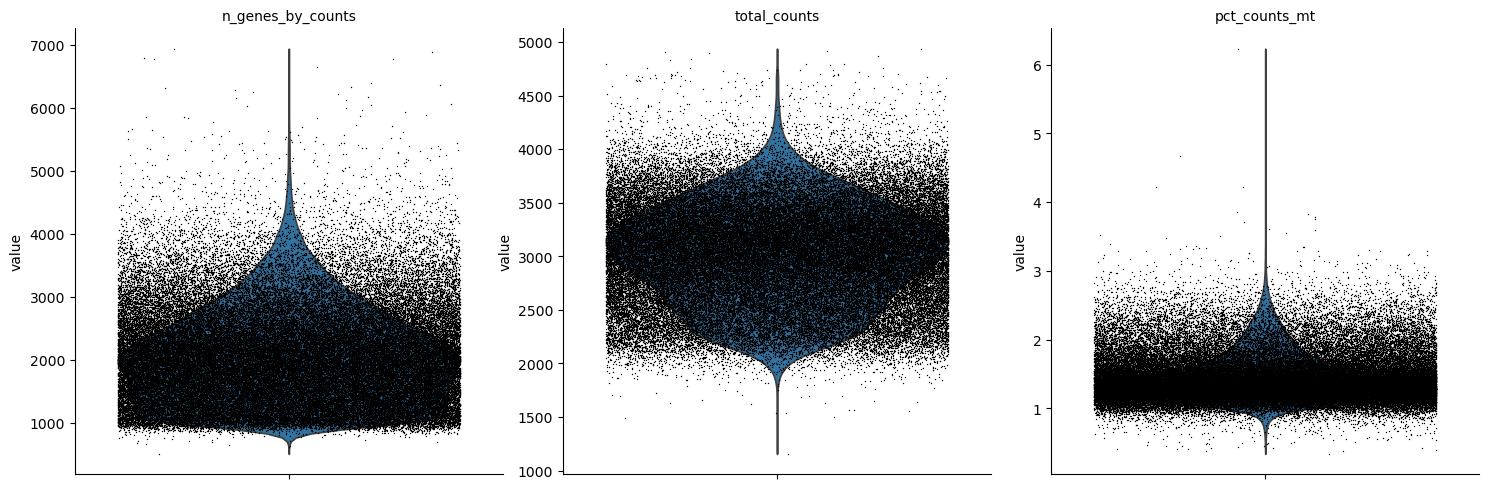

In [10]:
sc.pl.violin(
    g6_dz,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

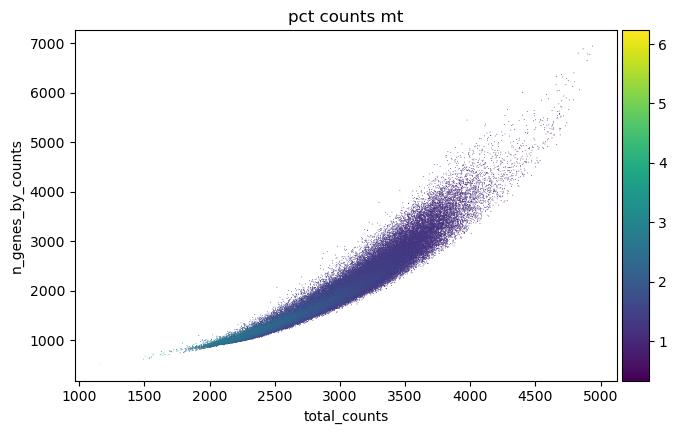

In [11]:
sc.pl.scatter(g6_dz, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
g6_dz.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe()


,n_genes_by_counts,total_counts,pct_counts_mt
count,79448.000000,79448.000000,79448.000000
mean,2067.614792,3010.909560,1.452496
std,753.584918,467.590268,0.350940
min,508.000000,1155.448979,0.338170
25%,1472.000000,2663.939872,1.214473
50%,1984.000000,3030.448013,1.370311
75%,2533.000000,3346.346647,1.605979
max,6941.000000,4936.461959,6.229855


#### Run scrublet for droplet quality control, splitting the data due to runtime

In [14]:
## we're constrained by the runtime below

rng = np.random.default_rng(42)
idx = np.arange(g6_dz.n_obs)
rng.shuffle(idx)


half = g6_dz.n_obs // 2
ix_A = g6_dz.obs_names[idx[:half]]
ix_B = g6_dz.obs_names[idx[half:]]

In [15]:
A = g6_dz[ix_A].copy()
B = g6_dz[ix_B].copy()

In [16]:
sc.pp.scrublet(A)

In [17]:
A

AnnData object with n_obs × n_vars = 39724 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'X_name', 'scrublet'
    layers: 'counts'

In [18]:
sc.pp.scrublet(B)

In [19]:
B

AnnData object with n_obs × n_vars = 39724 × 28099
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'X_name', 'scrublet'
    layers: 'counts'

In [22]:
# --- 3) Merge the results back onto the full object (align by cell barcodes)
g6_dz.obs['doublet_score'] = (
    pd.concat([A.obs['doublet_score'], B.obs['doublet_score']])
      .reindex(g6_dz.obs_names)
)

g6_dz.obs['predicted_doublet'] = (
    pd.concat([A.obs['predicted_doublet'], B.obs['predicted_doublet']])
      .reindex(g6_dz.obs_names)
)

In [23]:
g6_dz.obs[['doublet_score']].describe()


,doublet_score
count,79448.000000
mean,0.132734
std,0.086411
min,0.002682
25%,0.062953
50%,0.119622
75%,0.187026
max,0.723971


In [24]:
g6_dz.obs[['predicted_doublet']].describe()


,predicted_doublet
count,79448
unique,2
top,False
freq,79447


#### Plot the scrublet result

In [25]:
sc.pl.scrublet_score_distribution(g6_dz)

ValueError: Please run scrublet before trying to generate the scrublet plot.

#### Save our results to a qc folder

In [26]:
intermediate_directory = str(ANALYSIS_DIR / "data-objects/qc")
sc.write(f'{intermediate_directory}/doublet_egfDuod_G6_DZ.h5ad', g6_dz)